# Задания №1, 2. Реализация среды и определение системы

In [1]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [2]:
class TankEnv(gym.Env):
    def __init__(self, size=5, moving_goal=True, default_tank_pos = np.array([0, 0]), default_goal_pos = np.array([4, 4])):
        super().__init__()
        self.size = size
        self.moving_goal = moving_goal
        self.obstacles = {(1, 1), (1, 2), (3, 3)}
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf)
        self.action_space = spaces.Discrete(5)
        self.default_tank_pos = default_tank_pos
        self.default_goal_pos = default_goal_pos
        self.reset()

    def get_obs(self):
        tx, ty = self.tank_pos
        gx, gy = self.goal
        dist = np.sqrt((gx - tx)**2 + (gy - ty)**2)
        angle_to_goal = np.degrees(np.arctan2(gy - ty, gx - tx)) - self.tank_angle
        obs_near = [
            1 if (tx, ty+1) in self.obstacles or ty+1 >= self.size else 0,
            1 if (tx, ty-1) in self.obstacles or ty-1 < 0 else 0,
            1 if (tx-1, ty) in self.obstacles or tx-1 < 0 else 0,
            1 if (tx+1, ty) in self.obstacles or tx+1 >= self.size else 0
        ]
        return np.array([tx, ty, self.tank_angle, dist, angle_to_goal, *obs_near], dtype=np.float32)

    def reset(self, seed=None):
        super().reset(seed=seed)
        self.tank_pos = self.default_tank_pos.copy()
        self.tank_angle = 0
        self.goal = self.default_goal_pos.copy()
        self.step_count = 0
        return self.get_obs(), {}

    def move_goal(self):
        moves = [[0, 1], [0, -1], [1, 0], [-1, 0], [0, 0]]
        move = moves[np.random.randint(len(moves))]
        new_goal = self.goal + np.array(move)
        if (0 <= new_goal[0] < self.size and 0 <= new_goal[1] < self.size and tuple(new_goal) not in self.obstacles):
            self.goal = new_goal

    def step(self, action):
        self.last_action = action
        old_pos = self.tank_pos.copy()
        self.step_count += 1
        reward = -1
        terminated = False

        if self.moving_goal:
            self.move_goal()

        rad = np.radians(self.tank_angle)

        if action == 4:
            dx, dy = int(np.round(np.cos(rad))), int(np.round(np.sin(rad)))
            curr_x, curr_y = self.tank_pos
            for _ in range(1, self.size):
                curr_x += dx
                curr_y += dy
                if not (0 <= curr_x < self.size and 0 <= curr_y < self.size):
                    break
                if (curr_x, curr_y) in self.obstacles:
                    reward -= 2
                    break
                if np.array_equal([curr_x, curr_y], self.goal):
                    reward += 100
                    terminated = True
                    break
            if not terminated:
                reward -= 5
        else:
            if action == 0:
                self.tank_pos += np.array([int(np.round(np.cos(rad))), int(np.round(np.sin(rad)))])
            elif action == 1:
                self.tank_pos -= np.array([int(np.round(np.cos(rad))), int(np.round(np.sin(rad)))])
            elif action == 2:
                self.tank_angle = (self.tank_angle + 90) % 360
            elif action == 3:
                self.tank_angle = (self.tank_angle - 90) % 360

            self.tank_pos = np.clip(self.tank_pos, 0, self.size - 1)
            if tuple(self.tank_pos) in self.obstacles:
                reward -= 10
                self.tank_pos = old_pos
            if np.array_equal(self.tank_pos, self.goal):
                reward -= 20
                self.tank_pos = old_pos

        return self.get_obs(), reward, terminated, False, {}
    
    def render(self):
        if not hasattr(self, 'fig'):
            self.fig, self.ax = plt.subplots(figsize=(5, 5))
        self.ax.clear()
        self.ax.set_xticks(np.arange(-0.5, self.size, 1), minor=True)
        self.ax.set_yticks(np.arange(-0.5, self.size, 1), minor=True)
        self.ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
        self.ax.set_xlim(-0.5, self.size - 0.5)
        self.ax.set_ylim(-0.5, self.size - 0.5)

        for ox, oy in self.obstacles:
            self.ax.add_patch(plt.Rectangle((ox-0.5, oy-0.5), 1, 1, color='gray', alpha=0.8))
        self.ax.add_patch(plt.Circle((self.goal[0], self.goal[1]), 0.3, color='green'))

        tx, ty = self.tank_pos
        angle_rad = np.radians(self.tank_angle)
        self.ax.add_patch(plt.Circle((tx, ty), 0.35, color='blue', zorder=3))
        dx, dy = 0.45 * np.cos(angle_rad), 0.45 * np.sin(angle_rad)
        self.ax.plot([tx, tx + dx], [ty, ty + dy], color='black', linewidth=3)

        if hasattr(self, 'last_action') and self.last_action == 4:
            rad = np.radians(self.tank_angle)
            end_x = tx + self.size * np.cos(rad)
            end_y = ty + self.size * np.sin(rad)
            self.ax.plot([tx, end_x], [ty, end_y], color='red', linestyle='--', alpha=0.6, zorder=5)
            self.ax.set_title("Fire")

        self.ax.set_title(f"Tank Pos: {self.tank_pos}, Angle: {self.tank_angle}°")
        clear_output(wait=True)
        display(self.fig)
        plt.close(self.fig)

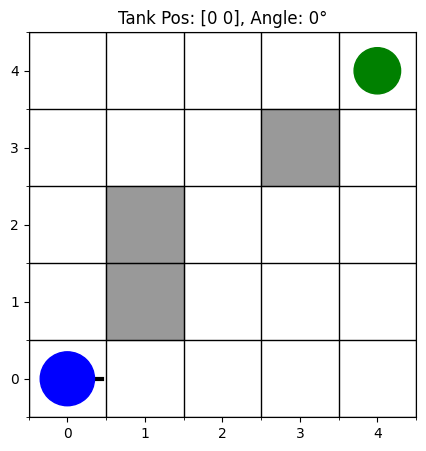

In [3]:
env = TankEnv(default_tank_pos = np.array([0, 0]), default_goal_pos = np.array([4, 4]))
env.render()

# Задание №3. «Реализация агента»

In [4]:
import random

class QLearningAgent:
    def __init__(self, action_dim, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon = 0.01):
        self.q_table = {} 
        self.action_dim = action_dim
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

    def get_q(self, state):
        state_key = tuple(state)
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_dim)
        return self.q_table[state_key]

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            return np.argmax(self.get_q(state))

    def learn(self, state, action, reward, next_state, done):
        old_q = self.get_q(state)[action]
        next_max = np.max(self.get_q(next_state))
        
        new_q = old_q + self.alpha * (reward + self.gamma * next_max * (1 - done) - old_q)
        self.q_table[tuple(state)][action] = new_q
        
        if done:
            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)


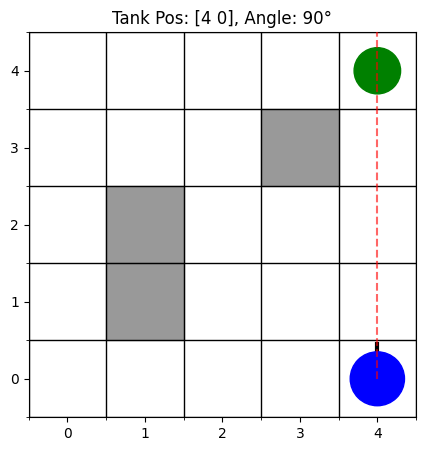

Эпизод 500 завершен


In [5]:
import time

env = TankEnv()
agent = QLearningAgent(action_dim=env.action_space.n)
episodes = 500
show_every = 100 
rewards_history = []


for episode in range(episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    
    render_this_ep = (episode + 1) % show_every == 0

    while not done:
        action = agent.choose_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        agent.learn(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        if render_this_ep:
            env.render()
            time.sleep(0.01)
    
    rewards_history.append(total_reward)

    if render_this_ep:
        print(f"Эпизод {episode+1} завершен")
        time.sleep(1)


# Задание №4. «Тестирование и анализ»

In [6]:
def test_agent(env, agent, num_episodes):
    agent.epsilon = 0
    for ep in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        
        while not done:
            action = agent.choose_action(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            
            env.render()
            time.sleep(0.01)
            
        print(f"Итерация: {ep+1}, Итоговая награда: {total_reward}")

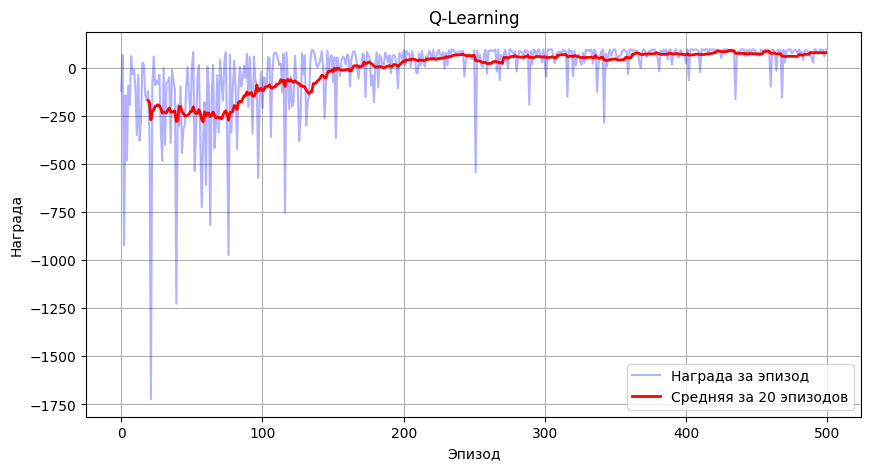

In [7]:
def plot_learning(rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, alpha=0.3, color='blue', label='Награда за эпизод')
    
    if len(rewards) > 20:
        avg_rewards = np.convolve(rewards, np.ones(20)/20, mode='valid')
        plt.plot(range(19, len(rewards)), avg_rewards, color='red', linewidth=2, label='Средняя за 20 эпизодов')
    
    plt.title("Q-Learning")
    plt.xlabel("Эпизод")
    plt.ylabel("Награда")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning(rewards_history)

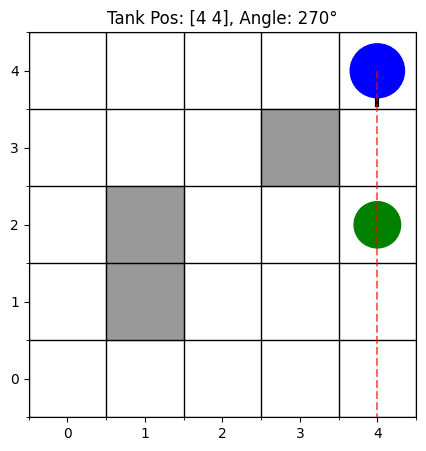

Итерация: 1, Итоговая награда: 81


In [10]:
env_test = TankEnv(size=5, moving_goal=True, default_tank_pos=np.array([4, 4]), default_goal_pos=np.array([0, 0]))

test_agent(env_test, agent, num_episodes=1)